<h1 style="text-align:center; font-size: 5em;">Project: Python Game Development</h1>
<hr style="border:2px solid">
<h1 style="text-align:center; font-size: 3em;">Project Overview</h1>
<hr style="border-top:1px dashed">


## Welcome to the First Python Project! 

Create a simple and interactive game using Python, incorporating fundamental programming concepts and Python basics. This project aims to reinforce your understanding of core Python principles while fostering creativity through game development. 

### Game options:

#### Guess the Number:

The computer randomly selects a number, and the player has to guess it.
Provide hints like "too high" or "too low" after each guess.
Include a limited number of attempts and a score system based on accuracy.

#### Hangman:

Create a word bank and randomly select a word for the player to guess.
Display the current state of the word with blanks for unrevealed letters.
Allow a limited number of incorrect guesses before the game ends.

#### Tic-Tac-Toe:

Implement a two-player Tic-Tac-Toe game.
Ensure proper input validation and display the game board after each move.
Declare the winner or a draw when the game concludes.

__Note: you can explore implementiong any other game of your choice.__


## Requirements

This project has two types of requirements:

### Technical Requirements:
Technical Requirements are designed to guide you on your project. These will help point you in the right direction as well as show you what we will be looking for when reviewing your project. These requirements will be focused towards the specific coding aspects you use.

### Functional Requirements:
Functional Requirements are designed to provoke thought throughout your project. These will be based in theory rather than code. These requirements will assist in shaping your output of each task.

#### Make sure to read the instructions thoroughly.

<hr style="border:2px solid">
<h1 style="text-align:center; font-size: 3em;">Project Requirements</h1>
<hr style="border-top:1px dashed">

### Functional Requirements:

- Use functions to modularise your code and promote code readability.
- Implement proper error handling for user inputs to avoid crashes.
- Ensure the game provides clear instructions and feedback to the player.
- Add comments to explain complex sections of your code.
- Create a README file that includes instructions on how to play the game.
- Have statistics of the games. 

__Optional:__ 

- Implement a graphical user interface (GUI) using libraries like Pygame or Tkinter.
- Add sound effects or background music to enhance the gaming experience.
- Create additional levels or features to make the game more challenging.

### Code Requirements:

This project will require an assortment of counter variables that will have to be set on a global scale (they exist outside of all functions). It will also be required to use at least two function that you write. I would recommend you create the barebones of the game, then pretty it up. Do not worry about making incredibly detailed print statements and formatting until you finish the base game.

- Provide flowchart.
- Write at least two functions.
- Check the user input for any types of non-numeric answers or those that are not expected by the program (when applicable).
- Use several global counters to keep track of user's statistics.
- Code must have comment's explaining what you did following coding style standars and documentaton best practices.


### Deliverables: 

- Flowchart.
- Python script or Jupyter Notebook with the game.
- GitHub Repo.
- README file.
- Up to 3 min video presentation sowcasing the game.

***Note on AI Use***: 
We understand that AI tools can be helpful in coding, and we do not discourage their use. However, for this project, we strongly encourage you to minimise your reliance on AI. This is a crucial stage in your learning journey, and working through the problems yourself will help you build a solid understanding of Python fundamentals. Overusing AI at this point may hinder your ability to grasp key concepts and develop problem-solving skills that are essential for your growth as a programmer.


<hr style="border:2px solid">

---

### Part One:
> Please provide the Flowchart of your solution.

> These do not need to be overly detailed. Create basic short steps.


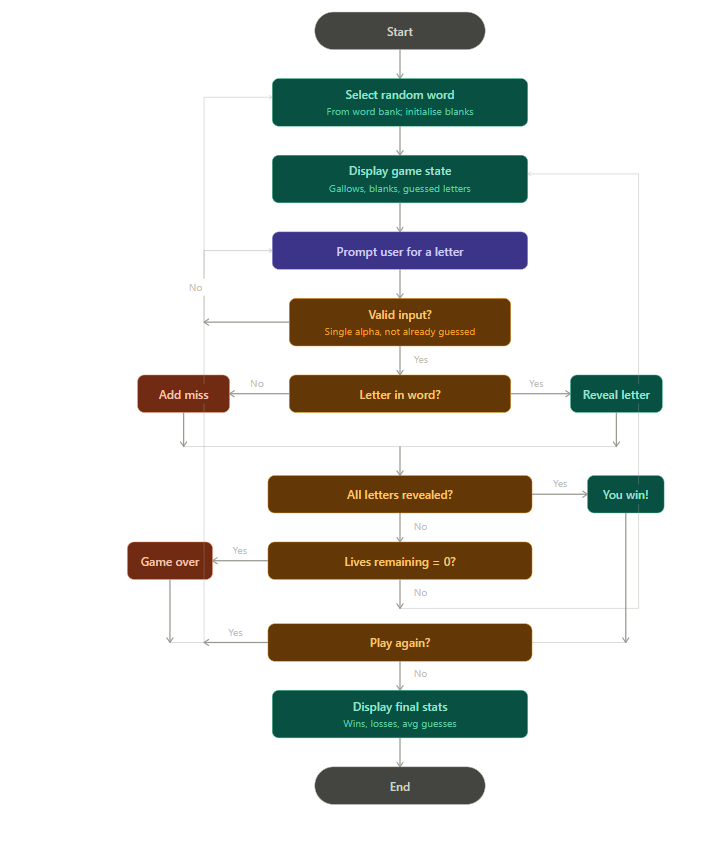

---

### Part Two:
> Build it!

> Write your code below.

> Work towards a minimal viable product before working on making your output pretty.

In [1]:
"""
Hangman Game
============
A command-line Hangman game with input validation, game statistics,
and a gallows display that updates with each wrong guess.

Author : Izzam Golamaully
Date   : 08.05.2026
"""

import random

# ---------------------------------------------------------------------------
# Global statistics counters (persist across multiple rounds in one session)
# ---------------------------------------------------------------------------
total_games   = 0   # Number of completed games
total_wins    = 0   # Number of games won
total_losses  = 0   # Number of games lost
total_guesses = 0   # Cumulative guesses across all games

# ---------------------------------------------------------------------------
# Constants
# ---------------------------------------------------------------------------
MAX_WRONG = 6  # Maximum wrong guesses before game over

WORD_BANK = [
    "python", "hangman", "keyboard", "library", "function",
    "variable", "algorithm", "debugging", "recursion", "iterator",
    "dictionary", "boolean", "exception", "parameter", "argument",
]

# Gallows stages — each string in the list is one ASCII art frame.
# Index = number of wrong guesses so far.
GALLOWS = [
    # 0 wrong
    """
  +---+
  |   |
      |
      |
      |
      |
=========""",
    # 1 wrong
    """
  +---+
  |   |
  O   |
      |
      |
      |
=========""",
    # 2 wrong
    """
  +---+
  |   |
  O   |
  |   |
      |
      |
=========""",
    # 3 wrong
    """
  +---+
  |   |
  O   |
 /|   |
      |
      |
=========""",
    # 4 wrong
    """
  +---+
  |   |
  O   |
 /|\  |
      |
      |
=========""",
    # 5 wrong
    """
  +---+
  |   |
  O   |
 /|\  |
 /    |
      |
=========""",
    # 6 wrong — fully hanged
    """
  +---+
  |   |
  O   |
 /|\  |
 / \  |
      |
=========""",
]


# ---------------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------------

def choose_word():
    """
    Randomly select and return a word from the word bank.

    Returns
    -------
    str
        A lowercase word for the player to guess.
    """
    return random.choice(WORD_BANK)


def get_display(word, guessed_letters):
    """
    Build the blanks/letters display string for the current word.

    Each character in the word is shown if it has been guessed,
    otherwise it is shown as an underscore with spaces for readability.

    Parameters
    ----------
    word : str
        The secret word.
    guessed_letters : set
        Set of letters the player has already guessed.

    Returns
    -------
    str
        A string like '_ _ p _ h _' representing the current state.
    """
    return " ".join(letter if letter in guessed_letters else "_"
                    for letter in word)


def get_valid_guess(guessed_letters):
    """
    Prompt the player for a single alphabetic letter and validate it.

    Keeps prompting until the player enters:
      - exactly one character
      - an alphabetic character
      - a letter not already guessed this round

    Parameters
    ----------
    guessed_letters : set
        Letters already guessed so far; used to catch repeats.

    Returns
    -------
    str
        A single lowercase letter that passes all validation checks.
    """
    while True:
        guess = input("Enter a letter: ").strip().lower()

        if len(guess) != 1:
            print("  ✗  Please enter exactly ONE letter.")
        elif not guess.isalpha():
            print("  ✗  Letters only — no numbers or symbols.")
        elif guess in guessed_letters:
            print(f"  ✗  You already guessed '{guess}'. Try another.")
        else:
            return guess


def display_state(word, guessed_letters, wrong_guesses, wrong_letters):
    """
    Print the gallows, the current word display, and the missed letters.

    Parameters
    ----------
    word : str
        The secret word.
    guessed_letters : set
        All letters guessed so far (correct and incorrect).
    wrong_guesses : int
        Number of incorrect guesses made.
    wrong_letters : list
        List of incorrect letters guessed so far.
    """
    print(GALLOWS[wrong_guesses])
    print(f"\n  Word  : {get_display(word, guessed_letters)}")
    print(f"  Wrong : {', '.join(sorted(wrong_letters)) or 'None'}")
    print(f"  Lives : {MAX_WRONG - wrong_guesses} remaining\n")


def play_round():
    """
    Run a single round of Hangman and update global statistics.

    Selects a random word, loops through the guess-validate-feedback
    cycle until the player either wins (all letters revealed) or
    loses (wrong guesses reach MAX_WRONG), then updates the global
    counters.

    Returns
    -------
    bool
        True if the player won this round, False otherwise.
    """
    global total_games, total_wins, total_losses, total_guesses

    word            = choose_word()
    guessed_letters = set()   # All guesses (right + wrong)
    wrong_letters   = []      # Only wrong guesses
    wrong_guesses   = 0
    round_guesses   = 0       # Guesses taken this round

    print("\n" + "=" * 42)
    print("  N E W   G A M E")
    print("=" * 42)
    print(f"  The word has {len(word)} letter(s). Good luck!\n")

    while True:
        display_state(word, guessed_letters, wrong_guesses, wrong_letters)

        # --- Check win condition ---
        if all(letter in guessed_letters for letter in word):
            print(f"  🎉  You got it! The word was '{word}'.")
            total_wins  += 1
            total_games += 1
            total_guesses += round_guesses
            return True

        # --- Check lose condition ---
        if wrong_guesses >= MAX_WRONG:
            print(f"  💀  You've been hanged! The word was '{word}'.")
            total_losses += 1
            total_games  += 1
            total_guesses += round_guesses
            return False

        # --- Get and process guess ---
        guess = get_valid_guess(guessed_letters)
        guessed_letters.add(guess)
        round_guesses += 1

        if guess in word:
            count = word.count(guess)
            print(f"  ✓  '{guess}' is in the word! ({count} occurrence(s))")
        else:
            wrong_letters.append(guess)
            wrong_guesses += 1
            print(f"  ✗  '{guess}' is not in the word.")


def show_stats():
    """
    Print the player's cumulative session statistics.

    Displays total games played, wins, losses, win rate, and
    the average number of guesses per game.
    """
    print("\n" + "=" * 42)
    print("  S E S S I O N   S T A T S")
    print("=" * 42)
    print(f"  Games played : {total_games}")
    print(f"  Wins         : {total_wins}")
    print(f"  Losses       : {total_losses}")

    if total_games > 0:
        win_rate = (total_wins / total_games) * 100
        avg_guesses = total_guesses / total_games
        print(f"  Win rate     : {win_rate:.1f}%")
        print(f"  Avg guesses  : {avg_guesses:.1f}")

    print("=" * 42)


# ---------------------------------------------------------------------------
# Main entry point
# ---------------------------------------------------------------------------

def main():
    """
    Main game loop — greets the player and repeatedly runs rounds
    until the player chooses to quit, then prints session stats.
    """
    print("\n" + "=" * 42)
    print("  Welcome to H A N G M A N !")
    print("  Guess the word one letter at a time.")
    print(f"  You get {MAX_WRONG} wrong guesses per round.")
    print("=" * 42)

    while True:
        play_round()

        # --- Play again prompt ---
        while True:
            again = input("\n  Play again? (y/n): ").strip().lower()
            if again in ("y", "n"):
                break
            print("  Please enter 'y' or 'n'.")

        if again == "n":
            break

    show_stats()
    print("\n  Thanks for playing! Goodbye. 👋\n")


# Run the game only when this script is executed directly,
# not when it is imported as a module.
if __name__ == "__main__":
    main()

<>:72: SyntaxWarning: invalid escape sequence '\ '
<>:81: SyntaxWarning: invalid escape sequence '\ '
<>:90: SyntaxWarning: invalid escape sequence '\ '
<>:72: SyntaxWarning: invalid escape sequence '\ '
<>:81: SyntaxWarning: invalid escape sequence '\ '
<>:90: SyntaxWarning: invalid escape sequence '\ '
C:\Users\Izzam\AppData\Local\Temp\ipykernel_17816\3463719815.py:72: SyntaxWarning: invalid escape sequence '\ '
  """
C:\Users\Izzam\AppData\Local\Temp\ipykernel_17816\3463719815.py:81: SyntaxWarning: invalid escape sequence '\ '
  """
C:\Users\Izzam\AppData\Local\Temp\ipykernel_17816\3463719815.py:90: SyntaxWarning: invalid escape sequence '\ '
  """



  Welcome to H A N G M A N !
  Guess the word one letter at a time.
  You get 6 wrong guesses per round.

  N E W   G A M E
  The word has 10 letter(s). Good luck!


  +---+
  |   |
      |
      |
      |
      |

  Word  : _ _ _ _ _ _ _ _ _ _
  Wrong : None
  Lives : 6 remaining

  ✗  'p' is not in the word.

  +---+
  |   |
  O   |
      |
      |
      |

  Word  : _ _ _ _ _ _ _ _ _ _
  Wrong : p
  Lives : 5 remaining

  ✓  'd' is in the word! (1 occurrence(s))

  +---+
  |   |
  O   |
      |
      |
      |

  Word  : d _ _ _ _ _ _ _ _ _
  Wrong : p
  Lives : 5 remaining

  ✓  'i' is in the word! (2 occurrence(s))

  +---+
  |   |
  O   |
      |
      |
      |

  Word  : d i _ _ i _ _ _ _ _
  Wrong : p
  Lives : 5 remaining

  ✓  'c' is in the word! (1 occurrence(s))

  +---+
  |   |
  O   |
      |
      |
      |

  Word  : d i c _ i _ _ _ _ _
  Wrong : p
  Lives : 5 remaining

  ✗  You already guessed 'c'. Try another.
  ✓  't' is in the word! (1 occurrence(s))

  +---+
  |

### Python Game Project

| Subject                                   | 1–2 Marks                                                                                                                                                                                                 | 3–4 Marks                                                                                                                                                                                                 | 5 Marks                                                                                                                                                                                                                  |
|--------------------------------------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Game Logic & Design (Flowchart)**        | Flowchart is unclear, incomplete, or does not represent the game logic accurately. Major steps or decisions are missing, or the flow is confusing and hard to follow.                                     | Flowchart covers most main steps and decisions, but may have some missing elements or minor clarity issues. Logic is mostly correct but could be clearer.                                                | Flowchart is clear, complete, and accurately represents the game’s logic and structure. All key decisions and steps are included, and the flow is easy to follow.                                                        |
| **Technical Implementation & Effectiveness** | Functions are missing, poorly structured, or not used appropriately. Code does not follow best practices (e.g., poor naming, repetition, lack of modularity). Game does not work as intended, has major errors, or is not engaging. Poor error handling. | Functions are present and mostly appropriate, but may lack clarity or consistency. Some best practices are followed, but there are areas for improvement. Game mostly works, but may have some issues or lack engagement. Some error handling present. | Functions are well-designed, clearly named, and used effectively to structure the code. Code follows best practices throughout, is clean, well-organised, and easy to read. Game works well, is engaging, and handles errors effectively. |
| **Documentation & Presentation**           | Code is difficult to read, poorly commented, and lacks docstrings. Variable and function names are unclear. No or minimal documentation. README file is missing or unhelpful. Presentation is missing or unclear.             | Some comments and docstrings are present, but may lack detail or consistency. Code is somewhat readable, but could be improved. README file is present but basic or incomplete. Presentation covers basics but lacks detail or clarity.                   | Code is well-documented, with comprehensive comments and clear docstrings. Naming is clear and consistent. README file is clear, detailed, and helpful. Presentation is clear, confident, and explains the game’s features and logic well.              |
